# 06 - Model Evaluation and Business Output

Combines the backtest results from notebooks 04 (naive, seasonal naive, moving average, Holt-Winters, SARIMA) and 05 (XGBoost) into one comparison, selects the best-performing model **per category** rather than assuming one algorithm wins everywhere, and produces the final forecast + stock-risk table.

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = Path("../images")

conn = sqlite3.connect(PROCESSED_DIR / "pharma_sales.db")
categories = pd.read_sql("SELECT * FROM dim_category", conn)
CODE_TO_NAME = dict(zip(categories["category_code"], categories["category_name"]))
codes = sorted(CODE_TO_NAME)

monthly = pd.read_sql(
    "SELECT sale_date, category_code, units_sold FROM fact_sales WHERE granularity = 'monthly'",
    conn, parse_dates=["sale_date"]
)
monthly = monthly[monthly["sale_date"] <= "2019-09-30"].sort_values("sale_date")

def get_series(code):
    return monthly[monthly["category_code"] == code].set_index("sale_date")["units_sold"].asfreq("ME")

series = {code: get_series(code) for code in codes}

## Combine all backtest results

In [2]:
ts_backtest = pd.read_csv(PROCESSED_DIR / "backtest_results_ts_models.csv", parse_dates=["origin_date"])
ml_backtest = pd.read_csv(PROCESSED_DIR / "backtest_results_ml.csv", parse_dates=["origin_date"])
all_backtest = pd.concat([ts_backtest, ml_backtest], ignore_index=True)

def summarize_errors(df):
    err = df["actual"] - df["predicted"]
    mae = err.abs().mean()
    rmse = np.sqrt((err ** 2).mean())
    mape = (err.abs() / df["actual"].abs()).mean() * 100
    return pd.Series({"MAE": mae, "RMSE": rmse, "MAPE": mape})

comparison = (
    all_backtest.groupby(["category_code", "model", "horizon"])
    .apply(summarize_errors, include_groups=False)
    .reset_index()
)
comparison.round(2).head(10)

,category_code,model,horizon,MAE,RMSE,MAPE
0,M01AB,holt_winters,1,16.51,20.41,10.82
1,M01AB,holt_winters,3,16.38,20.92,10.62
2,M01AB,moving_average,1,15.84,18.22,10.40
3,M01AB,moving_average,3,12.57,16.03,7.99
4,M01AB,naive,1,18.12,21.50,11.95
5,M01AB,naive,3,19.22,22.49,12.47
6,M01AB,sarima,1,13.54,16.33,8.82
7,M01AB,sarima,3,14.02,17.38,8.82
8,M01AB,seasonal_naive,1,20.32,25.23,13.49
9,M01AB,seasonal_naive,3,19.80,24.44,13.00


## Overall model comparison (all categories pooled)

In [3]:
overall = (
    all_backtest.groupby(["model", "horizon"])
    .apply(summarize_errors, include_groups=False)
    .round(2)
    .sort_values("MAPE")
)
overall

MAE    RMSE   MAPE
model          horizon                      
sarima         1        34.99   70.67  18.40
               3        42.07   86.16  19.41
holt_winters   1        38.38   79.56  20.97
xgboost        1        40.72   73.84  21.45
naive          1        46.31   93.63  21.98
holt_winters   3        48.96   93.80  23.08
moving_average 1        53.36  109.58  24.23
xgboost        3        51.48   89.17  26.11
seasonal_naive 3        59.24  116.76  26.93
               1        60.65  117.50  28.23
naive          3        71.79  149.98  31.89
moving_average 3        77.79  155.36  32.27

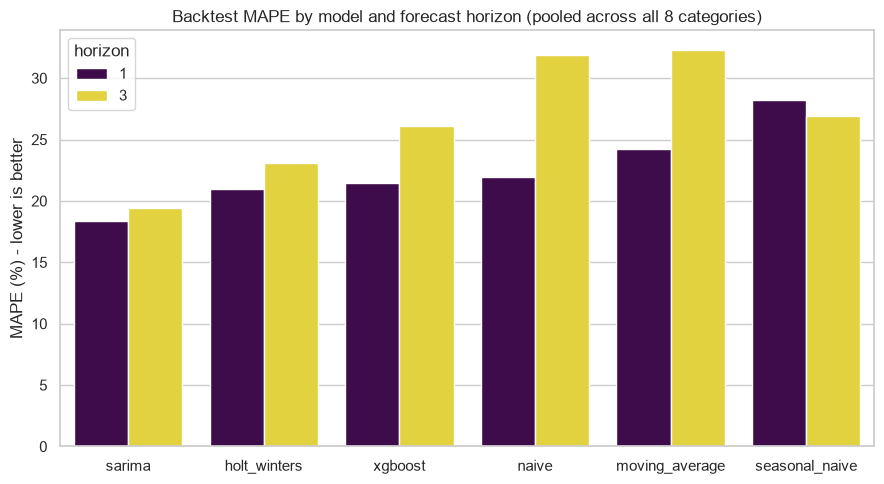

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = overall.reset_index()
sns.barplot(data=plot_data, x="model", y="MAPE", hue="horizon", ax=ax, palette="viridis")
ax.set_ylabel("MAPE (%) - lower is better")
ax.set_xlabel("")
ax.set_title("Backtest MAPE by model and forecast horizon (pooled across all 8 categories)")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "model_comparison_mape.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** pooled across all 8 categories, SARIMA is the best model at both horizons (18.4% MAPE at 1-month, 19.4% at 3-month), with Holt-Winters second (21.0% / 23.1%) and XGBoost third (21.5% / 26.1%) — consistent with notebooks 03-05's conclusion that with only 69 monthly points per category, models with built-in structure (seasonal ARIMA terms, exponential smoothing) generalize better than a model that has to learn the structure from the data itself. The naive baselines are not far behind SARIMA at 1-month (naive: 22.0%), which is a useful reality check — a sophisticated model needs to clearly beat "repeat last month" to justify its complexity, and here it does, but not by an overwhelming margin.

## Best model per category

Selected on 1-month-ahead MAPE, since that's the actionable near-term decision for a pharmacy restocking cycle. Deliberately not forcing one model on all 8 categories — notebooks 04 and 05 already showed SARIMA wins most but not all, and XGBoost never actually wins.

In [5]:
h1 = comparison[comparison["horizon"] == 1]
best_idx = h1.groupby("category_code")["MAPE"].idxmin()
best_model = h1.loc[best_idx, ["category_code", "model", "MAE", "RMSE", "MAPE"]].set_index("category_code")
best_model.columns = ["best_model", "mae_h1", "rmse_h1", "mape_h1"]

h3 = comparison[comparison["horizon"] == 3]
for code in codes:
    model = best_model.loc[code, "best_model"]
    row = h3[(h3["category_code"] == code) & (h3["model"] == model)]
    best_model.loc[code, "rmse_h3"] = row["RMSE"].iloc[0]
    best_model.loc[code, "mape_h3"] = row["MAPE"].iloc[0]

best_model.round(2)

,best_model,mae_h1,rmse_h1,mape_h1,rmse_h3,mape_h3
category_code,,,,,,
M01AB,sarima,13.54,16.33,8.82,17.38,8.82
M01AE,sarima,14.47,24.56,11.44,26.14,14.18
N02BA,moving_average,12.05,14.23,12.99,15.25,13.28
N02BE,sarima,121.87,177.98,12.47,221.27,17.99
N05B,sarima,29.53,38.37,11.37,41.71,11.94
N05C,sarima,5.43,7.49,31.72,7.71,33.52
R03,holt_winters,48.47,60.34,25.03,63.94,24.93
R06,holt_winters,20.76,31.74,21.18,32.63,18.41


**Finding:** SARIMA wins 6 of 8 categories outright (M01AB 8.8%, M01AE 11.4%, N02BE 12.5%, N05B 11.4%, N05C 31.7% — still its weakest category, consistent with N05C's tiny base volume and highest outlier rate from notebook 02). Moving average wins N02BA (13.0% vs SARIMA's 15.2%) — its declining trend (found in notebook 03) is simple enough that a short trailing average tracks it about as well as a fitted model. Holt-Winters wins R03 and R06 (25.0% and 21.2%), the two strongest-seasonality categories, matching the notebook 04 result exactly. No category is won by a naive baseline or XGBoost, which is itself worth stating: added model complexity is earning its place here, just not uniformly the same complexity everywhere.

## Assemble final forecasts from each category's chosen model

SARIMA and XGBoost final forecasts already exist from notebooks 04-05. Naive, seasonal naive, moving average, and Holt-Winters are cheap enough to compute fresh here for whichever categories actually selected them.

**Prediction intervals are built from backtest RMSE (`forecast ± 1.96 x RMSE` at that horizon), not from each model's own internal interval.** This is deliberate: notebook 04 found SARIMA's residuals fail the Shapiro normality test for 6 of 8 categories, so its internally-reported Gaussian interval understates real uncertainty. An interval grounded in actual out-of-sample backtest error is more honest than trusting a model's self-reported confidence, and it also gives every model type (including the baselines, which don't produce a statistical interval at all) a consistent, comparable interval.

In [6]:
sarima_final = pd.read_csv(PROCESSED_DIR / "final_sarima_forecasts.csv")
xgb_final = pd.read_csv(PROCESSED_DIR / "final_xgboost_forecasts.csv")

def best_seasonal_type(s):
    add = seasonal_decompose(s, model="additive", period=12, extrapolate_trend="freq")
    if (s > 0).all():
        mul = seasonal_decompose(s, model="multiplicative", period=12, extrapolate_trend="freq")
        if mul.resid.std() < add.resid.std() / s.mean():
            return "mul"
    return "add"

def get_point_forecast(code, model):
    s = series[code]
    if model == "sarima":
        rows = sarima_final[sarima_final["category_code"] == code]
        return rows[rows["horizon"] == 1]["forecast"].iloc[0], rows[rows["horizon"] == 3]["forecast"].iloc[0]
    if model == "xgboost":
        rows = xgb_final[xgb_final["category_code"] == code]
        return rows[rows["horizon"] == 1]["forecast"].iloc[0], rows[rows["horizon"] == 3]["forecast"].iloc[0]
    if model == "naive":
        v = s.iloc[-1]
        return v, v
    if model == "seasonal_naive":
        return s.iloc[-12], s.iloc[-10]
    if model == "moving_average":
        v = s.iloc[-3:].mean()
        return v, v
    if model == "holt_winters":
        seasonal_type = best_seasonal_type(s)
        fitted = ExponentialSmoothing(s, trend="add", seasonal=seasonal_type, seasonal_periods=12).fit(optimized=True)
        fc = fitted.forecast(3)
        return fc.iloc[0], fc.iloc[2]
    raise ValueError(model)

final_rows = []
for code in codes:
    model = best_model.loc[code, "best_model"]
    fc_h1, fc_h3 = get_point_forecast(code, model)
    rmse_h1, rmse_h3 = best_model.loc[code, "rmse_h1"], best_model.loc[code, "rmse_h3"]

    final_rows.append({
        "category_code": code,
        "category_name": CODE_TO_NAME[code],
        "best_model": model,
        "current_avg_monthly_sales": series[code].iloc[-3:].mean(),
        "next_month_forecast": fc_h1,
        "next_month_ci_lower": max(0, fc_h1 - 1.96 * rmse_h1),
        "next_month_ci_upper": fc_h1 + 1.96 * rmse_h1,
        "month3_forecast": fc_h3,
        "month3_ci_lower": max(0, fc_h3 - 1.96 * rmse_h3),
        "month3_ci_upper": fc_h3 + 1.96 * rmse_h3,
        "backtest_mape_h1": best_model.loc[code, "mape_h1"],
        "backtest_mape_h3": best_model.loc[code, "mape_h3"],
    })

final_table = pd.DataFrame(final_rows)
final_table.round(1)

,category_code,category_name,best_model,current_avg_monthly_sales,next_month_forecast,next_month_ci_lower,next_month_ci_upper,month3_forecast,month3_ci_lower,month3_ci_upper,backtest_mape_h1,backtest_mape_h3
0,M01AB,Anti-inflammatory (acetic acid derivatives),sarima,174.7,166.9,134.9,198.9,167.6,133.6,201.7,8.8,8.8
1,M01AE,Anti-inflammatory (propionic acid derivatives),sarima,101.1,119.5,71.4,167.7,120.0,68.8,171.2,11.4,14.2
2,N02BA,Analgesics - salicylic acid derivatives,moving_average,90.2,90.2,62.3,118.0,90.2,60.3,120.1,13.0,13.3
3,N02BE,Analgesics - pyrazolones and anilides,sarima,717.5,1083.6,734.7,1432.4,957.2,523.5,1390.9,12.5,18.0
4,N05B,Anxiolytics,sarima,238.5,241.2,166.0,316.4,255.6,173.9,337.4,11.4,11.9
5,N05C,Hypnotics and sedatives,sarima,20.7,17.5,2.8,32.1,17.9,2.8,33.0,31.7,33.5
6,R03,Anti-asthmatic and COPD drugs,holt_winters,140.3,341.0,222.7,459.3,363.6,238.2,488.9,25.0,24.9
7,R06,Antihistamines,holt_winters,103.9,81.5,19.3,143.7,52.0,0.0,116.0,21.2,18.4


## Stock-risk classification

Based on the percentage change between next month's forecast and the trailing 3-month average, with explicit thresholds rather than a vague label. No real inventory/stock-on-hand data exists in this dataset, so this is a demand-direction signal (a proxy for restocking urgency), not a literal days-of-stock calculation — stated explicitly here rather than implied.

In [7]:
final_table["pct_change_vs_current"] = (
    (final_table["next_month_forecast"] - final_table["current_avg_monthly_sales"])
    / final_table["current_avg_monthly_sales"] * 100
)

def classify_risk(pct):
    if pct > 10:
        return "High Demand"
    if pct < -10:
        return "Declining"
    return "Stable"

final_table["risk_category"] = final_table["pct_change_vs_current"].apply(classify_risk)
final_table[["category_name", "current_avg_monthly_sales", "next_month_forecast", "pct_change_vs_current", "risk_category"]].round(1)

,category_name,current_avg_monthly_sales,next_month_forecast,pct_change_vs_current,risk_category
0,Anti-inflammatory (acetic acid derivatives),174.7,166.9,-4.5,Stable
1,Anti-inflammatory (propionic acid derivatives),101.1,119.5,18.2,High Demand
2,Analgesics - salicylic acid derivatives,90.2,90.2,0.0,Stable
3,Analgesics - pyrazolones and anilides,717.5,1083.6,51.0,High Demand
4,Anxiolytics,238.5,241.2,1.1,Stable
5,Hypnotics and sedatives,20.7,17.5,-15.5,Declining
6,Anti-asthmatic and COPD drugs,140.3,341.0,143.0,High Demand
7,Antihistamines,103.9,81.5,-21.5,Declining


In [8]:
same_month_last_year = {}
for code in codes:
    target_date = series[code].index[-1] + pd.DateOffset(months=1) - pd.DateOffset(years=1)
    target_date = target_date + pd.offsets.MonthEnd(0)
    same_month_last_year[code] = series[code].get(target_date, np.nan)

final_table["same_month_last_year"] = final_table["category_code"].map(same_month_last_year)
final_table["pct_change_vs_last_year"] = (
    (final_table["next_month_forecast"] - final_table["same_month_last_year"])
    / final_table["same_month_last_year"] * 100
)

final_table[[
    "category_name", "current_avg_monthly_sales", "next_month_forecast",
    "pct_change_vs_current", "same_month_last_year", "pct_change_vs_last_year", "risk_category",
]].round(1)

,category_name,current_avg_monthly_sales,next_month_forecast,pct_change_vs_current,same_month_last_year,pct_change_vs_last_year,risk_category
0,Anti-inflammatory (acetic acid derivatives),174.7,166.9,-4.5,144.7,15.3,Stable
1,Anti-inflammatory (propionic acid derivatives),101.1,119.5,18.2,129.4,-7.6,High Demand
2,Analgesics - salicylic acid derivatives,90.2,90.2,0.0,76.1,18.6,Stable
3,Analgesics - pyrazolones and anilides,717.5,1083.6,51.0,1129.3,-4.0,High Demand
4,Anxiolytics,238.5,241.2,1.1,287.0,-16.0,Stable
5,Hypnotics and sedatives,20.7,17.5,-15.5,25.0,-30.1,Declining
6,Anti-asthmatic and COPD drugs,140.3,341.0,143.0,353.0,-3.4,High Demand
7,Antihistamines,103.9,81.5,-21.5,76.9,6.0,Declining


**Finding / limitation:** R03's forecast (341.0) is +143% versus its trailing 3-month average (140.3, Jul-Sep — R03's summer trough per the seasonality found in notebooks 02-03), which reads as an alarming spike and is labeled "High Demand" below. Checked against the actual year-over-year figure, October 2019's forecast is -3.4% versus October 2018's real value (353.0) — essentially flat, not an escalating spike; the trailing-average comparison was mostly picking up the normal summer-to-winter seasonal jump, not real excess growth. R06 shows the opposite failure mode: it's labeled "Declining" by the trailing-average metric (-21.5%) but is actually *up* +6.0% year-over-year — its trailing baseline (Jul-Sep) sits in R06's spring-adjacent shoulder season, so the comparison months themselves are inconsistent in a way that flips the label's meaning. The `Risk` column keeps the simpler trailing-average definition since it's easier to explain to a non-technical stakeholder, but for R03 and R06 specifically — the two most seasonal categories — `pct_change_vs_last_year` is the more trustworthy signal and should be read alongside it, not ignored.

## Final business table

In [9]:
business_table = final_table[[
    "category_name", "best_model", "current_avg_monthly_sales",
    "next_month_forecast", "next_month_ci_lower", "next_month_ci_upper",
    "month3_forecast", "risk_category", "backtest_mape_h1",
]].rename(columns={
    "category_name": "Product",
    "best_model": "Model Used",
    "current_avg_monthly_sales": "Current Avg Monthly Sales",
    "next_month_forecast": "Next Month Forecast",
    "next_month_ci_lower": "Next Month CI Lower",
    "next_month_ci_upper": "Next Month CI Upper",
    "month3_forecast": "Month+3 Forecast",
    "risk_category": "Risk",
    "backtest_mape_h1": "Backtest MAPE (1-month, %)",
}).round(1)

business_table.to_csv(PROCESSED_DIR / "final_business_forecast.csv", index=False)
business_table

,Product,Model Used,Current Avg Monthly Sales,Next Month Forecast,Next Month CI Lower,Next Month CI Upper,Month+3 Forecast,Risk,"Backtest MAPE (1-month, %)"
0,Anti-inflammatory (acetic acid derivatives),sarima,174.7,166.9,134.9,198.9,167.6,Stable,8.8
1,Anti-inflammatory (propionic acid derivatives),sarima,101.1,119.5,71.4,167.7,120.0,High Demand,11.4
2,Analgesics - salicylic acid derivatives,moving_average,90.2,90.2,62.3,118.0,90.2,Stable,13.0
3,Analgesics - pyrazolones and anilides,sarima,717.5,1083.6,734.7,1432.4,957.2,High Demand,12.5
4,Anxiolytics,sarima,238.5,241.2,166.0,316.4,255.6,Stable,11.4
5,Hypnotics and sedatives,sarima,20.7,17.5,2.8,32.1,17.9,Declining,31.7
6,Anti-asthmatic and COPD drugs,holt_winters,140.3,341.0,222.7,459.3,363.6,High Demand,25.0
7,Antihistamines,holt_winters,103.9,81.5,19.3,143.7,52.0,Declining,21.2


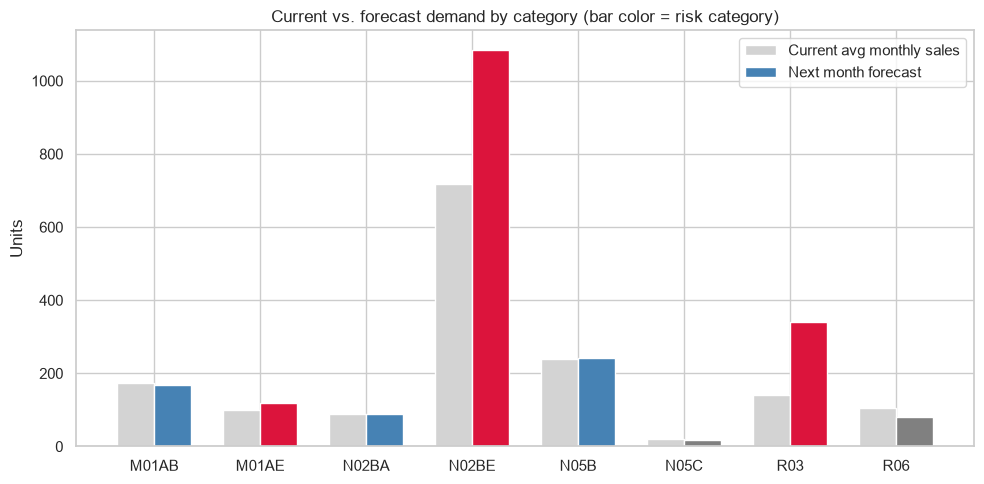

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"High Demand": "crimson", "Stable": "steelblue", "Declining": "gray"}
bar_colors = [colors[r] for r in final_table["risk_category"]]

x = np.arange(len(final_table))
width = 0.35
ax.bar(x - width / 2, final_table["current_avg_monthly_sales"], width, label="Current avg monthly sales", color="lightgray")
ax.bar(x + width / 2, final_table["next_month_forecast"], width, label="Next month forecast", color=bar_colors)
ax.set_xticks(x)
ax.set_xticklabels(final_table["category_code"], rotation=0)
ax.set_ylabel("Units")
ax.set_title("Current vs. forecast demand by category (bar color = risk category)")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "final_forecast_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
conn.close()